# 07 - BLR Recheck

After POC #5 revealed computational limits being reached under the previously set constraints, it became clear that constraints would need to be tweaked to reduce the load.

BLR resampling up by 3 and down by 20 took FS=16000 to FS=2400, with BW=2400 as a width safely containing each chirplet-filtered output channel's content. Increasing by a factor of 3 was the memory bottleneck, which is easily fixable by simply restricting the allowable chirplet bandwidth down to 2000 Hz or just using BW=4000, requiring only decimation in the resampling process. It is of more interest to restrict the BW to 2000 Hz to get memory savings on the output channels. This notebook's purpose is to find the upper chirplet bandwidth limit that safely stays within a BW=2000 width for BLR, i.e. a repeat of POC #4 with different parameters.

In [1]:
# Imports

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, resample_poly, hilbert, convolve
import soundfile as sf

import util
from util import pchirp, pick_bw_fc, bw_fc_to_f1f2, pick_val, get_bw_actual

# Constants now come from config.py (the shared source of truth that
# 03_dnn/frontend.py itself imports from), not from 01_poc/util.py, since
# this notebook is rechecking the values that will actually be used by the
# real front end.
REPO_ROOT = os.path.dirname(os.getcwd())
sys.path.insert(0, REPO_ROOT)
from config import (
    MIN_RATIO,
    MIN_BW,
    MAX_FREQ,
    MIN_FREQ,
    MAX_DUR_MS,
    MIN_DUR_MS,
    MAX_DEGREE,
    MIN_DEGREE,
    FS,
)

# pick_bw_fc / bw_fc_to_f1f2 / pchirp / get_bw_actual (imported above from
# util.py) all read their constraint constants off util's own module-level
# globals. Overwrite those globals with config.py's values so the reused
# util helpers operate under the config-driven constraints instead of
# util.py's own (possibly stale) copies. util.MAX_BW is intentionally left
# out here since Task 1 sweeps over candidate MAX_BW values directly.
util.MIN_RATIO = MIN_RATIO
util.MIN_BW = MIN_BW
util.MAX_FREQ = MAX_FREQ
util.MIN_FREQ = MIN_FREQ
util.MAX_DUR_MS = MAX_DUR_MS
util.MIN_DUR_MS = MIN_DUR_MS
util.MAX_DEGREE = MAX_DEGREE
util.MIN_DEGREE = MIN_DEGREE
util.FS = FS

%matplotlib widget

plt.close('all')

## Task 1 — Leakage sweep to find max safe `MAX_BW`

New target: a BLR bandwidth of **2000 Hz** (down from 2400 Hz in POC #4).

Method (same as POC #4, `04_bandpass_samp.ipynb`):
- Randomly sample chirplet design parameters (`pick_bw_fc`, `bw_fc_to_f1f2`, duration, degree) subject to the config-driven constraints, generate the chirplet (`pchirp`), zero-pad to a common length, and measure its *actual* empirical bandwidth at a -40 dB threshold (`get_bw_actual`) — the same threshold POC #4 settled on after finding stricter thresholds (-50/-60 dB) produced too many unusable (NaN) chirplets.
- Track the worst-case (maximum) empirical bandwidth seen across the sampled parameter space.

New twist for this notebook: instead of fixing `MAX_BW` and reporting the resulting worst-case leakage (as POC #4 did for `MAX_BW=1900` → worst-case ≈ 2388 Hz), sweep over a range of *candidate* `MAX_BW` values and, for each, measure the worst-case empirical bandwidth. Then pick the largest candidate `MAX_BW` whose worst-case empirical bandwidth still leaves a guard margin under the new 2000 Hz target — mirroring how POC #4 treated its own (fairly thin, ~12 Hz) margin between worst-case leakage (2388 Hz) and its BLR target (2400 Hz).

MAX_BW:  1500  ->  worst-case empirical BW (-40dB):   1961.0 Hz   (NaN%: 2.2)
MAX_BW:  1550  ->  worst-case empirical BW (-40dB):   1963.0 Hz   (NaN%: 1.7)
MAX_BW:  1600  ->  worst-case empirical BW (-40dB):   2022.0 Hz   (NaN%: 1.8)
MAX_BW:  1650  ->  worst-case empirical BW (-40dB):   2130.0 Hz   (NaN%: 1.8)
MAX_BW:  1700  ->  worst-case empirical BW (-40dB):   2157.0 Hz   (NaN%: 1.8)
MAX_BW:  1750  ->  worst-case empirical BW (-40dB):   2162.0 Hz   (NaN%: 1.9)
MAX_BW:  1800  ->  worst-case empirical BW (-40dB):   2231.0 Hz   (NaN%: 1.5)
Recommended MAX_BW: 1550 Hz
Worst-case empirical BW (-40dB) at recommended MAX_BW: 1963.0 Hz
New BLR target bandwidth: 2000 Hz
Guard margin achieved: 37.0 Hz (required >= 25 Hz)


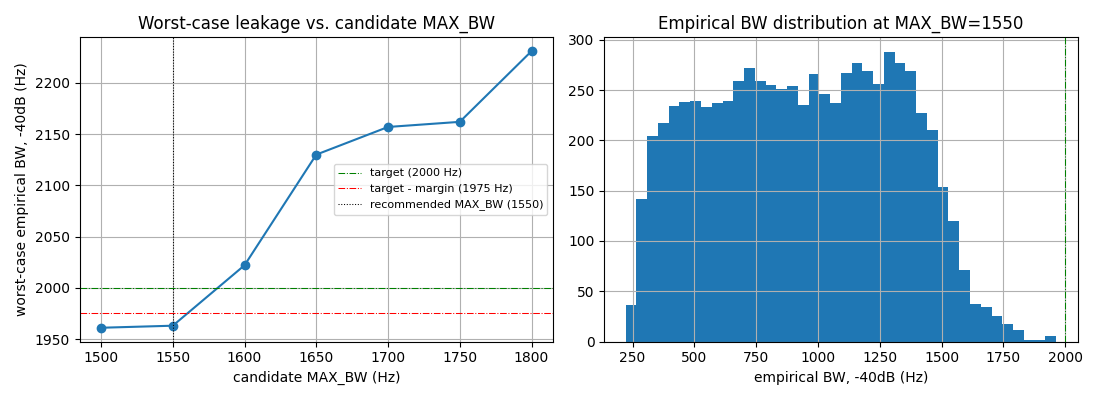

In [2]:
# Sweep candidate MAX_BW values, measuring worst-case empirical (-40dB) bandwidth for each
#
# For each candidate, temporarily set util.MAX_BW (pick_bw_fc reads this
# module-level global internally) then sample many random chirplets the
# same way POC #4 did, and record the worst-case (max) empirically measured
# bandwidth at -40dB.

NEW_BLR_TARGET_BW = 2000  # Hz, new BLR bandwidth target (was 2400 in POC #4)
T = 1.0  # seconds, common zero-pad length (same as POC #4)

N = 7500  # samples per candidate (same order of magnitude as POC #4's N)
candidate_max_bws = np.arange(1500, 1801, 50)  # old MAX_BW was 1900; new target is lower, so search down from there

sweep_results = {}  # candidate_max_bw -> array of worst/empirical bw samples

for cand in candidate_max_bws:
    util.MAX_BW = int(cand)

    bwe_samples = np.full(N, np.nan)

    for i in range(N):
        dur = pick_val(MIN_DUR_MS, MAX_DUR_MS)
        deg = pick_val(MIN_DEGREE, MAX_DEGREE)
        bw, fc = pick_bw_fc()
        f1, f2 = bw_fc_to_f1f2(bw, fc)
        ch = pchirp(f1, f2, dur, deg)
        chp = np.pad(ch, (0, int(FS * T - len(ch))))

        F1_40, F2_40 = get_bw_actual(chp, -40)
        bwe_samples[i] = np.abs(F2_40 - F1_40)

    sweep_results[int(cand)] = bwe_samples
    worst = np.nanmax(bwe_samples)
    nan_pct = 100. * np.isnan(bwe_samples).sum() / N
    print(f"MAX_BW: {int(cand):>5}  ->  worst-case empirical BW (-40dB): {worst:>8.1f} Hz   (NaN%: {nan_pct:.1f})")


# In[ ]:


# Pick the largest candidate MAX_BW that leaves a guard margin under the new 2000 Hz target
#
# POC #4's own margin (MAX_BW=1900 -> worst-case leakage 2388 Hz vs a 2400 Hz
# target) was only ~12 Hz. Here we require a somewhat larger, more
# deliberate guard margin (a round number, comparable in spirit) so the
# recommendation is safely, not just barely, under target.

GUARD_MARGIN = 25  # Hz

worst_per_candidate = {cand: np.nanmax(vals) for cand, vals in sweep_results.items()}

safe_candidates = [
    cand for cand, worst in worst_per_candidate.items()
    if worst <= NEW_BLR_TARGET_BW - GUARD_MARGIN
]

assert safe_candidates, "No candidate MAX_BW in the sweep range satisfies the guard margin; extend candidate_max_bws downward."

RECOMMENDED_MAX_BW = max(safe_candidates)
worst_at_recommended = worst_per_candidate[RECOMMENDED_MAX_BW]

print(f"Recommended MAX_BW: {RECOMMENDED_MAX_BW} Hz")
print(f"Worst-case empirical BW (-40dB) at recommended MAX_BW: {worst_at_recommended:.1f} Hz")
print(f"New BLR target bandwidth: {NEW_BLR_TARGET_BW} Hz")
print(f"Guard margin achieved: {NEW_BLR_TARGET_BW - worst_at_recommended:.1f} Hz (required >= {GUARD_MARGIN} Hz)")


# In[ ]:


# Diagnostic plot - distribution of worst-case empirical BW across the sweep, and histogram at the recommended MAX_BW

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

cands_sorted = sorted(worst_per_candidate.keys())
worst_sorted = [worst_per_candidate[c] for c in cands_sorted]

axs[0].plot(cands_sorted, worst_sorted, marker='o')
axs[0].axhline(NEW_BLR_TARGET_BW, color='g', linestyle='-.', linewidth=0.75, label=f'target ({NEW_BLR_TARGET_BW} Hz)')
axs[0].axhline(NEW_BLR_TARGET_BW - GUARD_MARGIN, color='r', linestyle='-.', linewidth=0.75, label=f'target - margin ({NEW_BLR_TARGET_BW - GUARD_MARGIN} Hz)')
axs[0].axvline(RECOMMENDED_MAX_BW, color='k', linestyle=':', linewidth=0.75, label=f'recommended MAX_BW ({RECOMMENDED_MAX_BW})')
axs[0].set_xlabel('candidate MAX_BW (Hz)')
axs[0].set_ylabel('worst-case empirical BW, -40dB (Hz)')
axs[0].set_title('Worst-case leakage vs. candidate MAX_BW')
axs[0].legend(fontsize=8)
axs[0].grid(which='both')

axs[1].hist(sweep_results[RECOMMENDED_MAX_BW][~np.isnan(sweep_results[RECOMMENDED_MAX_BW])], bins=40)
axs[1].axvline(NEW_BLR_TARGET_BW, color='g', linestyle='-.', linewidth=0.75)
axs[1].set_xlabel('empirical BW, -40dB (Hz)')
axs[1].set_title(f'Empirical BW distribution at MAX_BW={RECOMMENDED_MAX_BW}')
axs[1].grid(which='both')

plt.tight_layout()
plt.show()

# Restore util.MAX_BW to the recommended value for use in Task 2 below
util.MAX_BW = RECOMMENDED_MAX_BW

## Task 2 — Verify BLR end-to-end at the new bandwidth

Instantiate the real `BLR` module from `03_dnn/frontend.py` with `bandwidth=2000` and `fs=config.FS`, and run a few representative padded chirplets (built near the recommended `MAX_BW` found above) through it — the same padded-chirplet-as-impulse-response approach used in POC #4 (chirplet -> Hilbert -> demodulate -> decimate), just using the actual `BLR` class instead of the loose `hilbert` / `resample_poly` calls from POC #4.

Checks:
- Output magnitude envelope
- I/Q (real/imag) parts
- Post-demodulation spectrum, to confirm content stays centered near baseband, within the new decimated Nyquist (`bandwidth / 2` = 1000 Hz)

BLR()
Decimation factor (FS / bandwidth): 8
kernels shape: (3, 1301)
x shape: (1, 3, 16000)
Output shape: (1, 3, 2000)
Expected output length (BW * duration): 2000


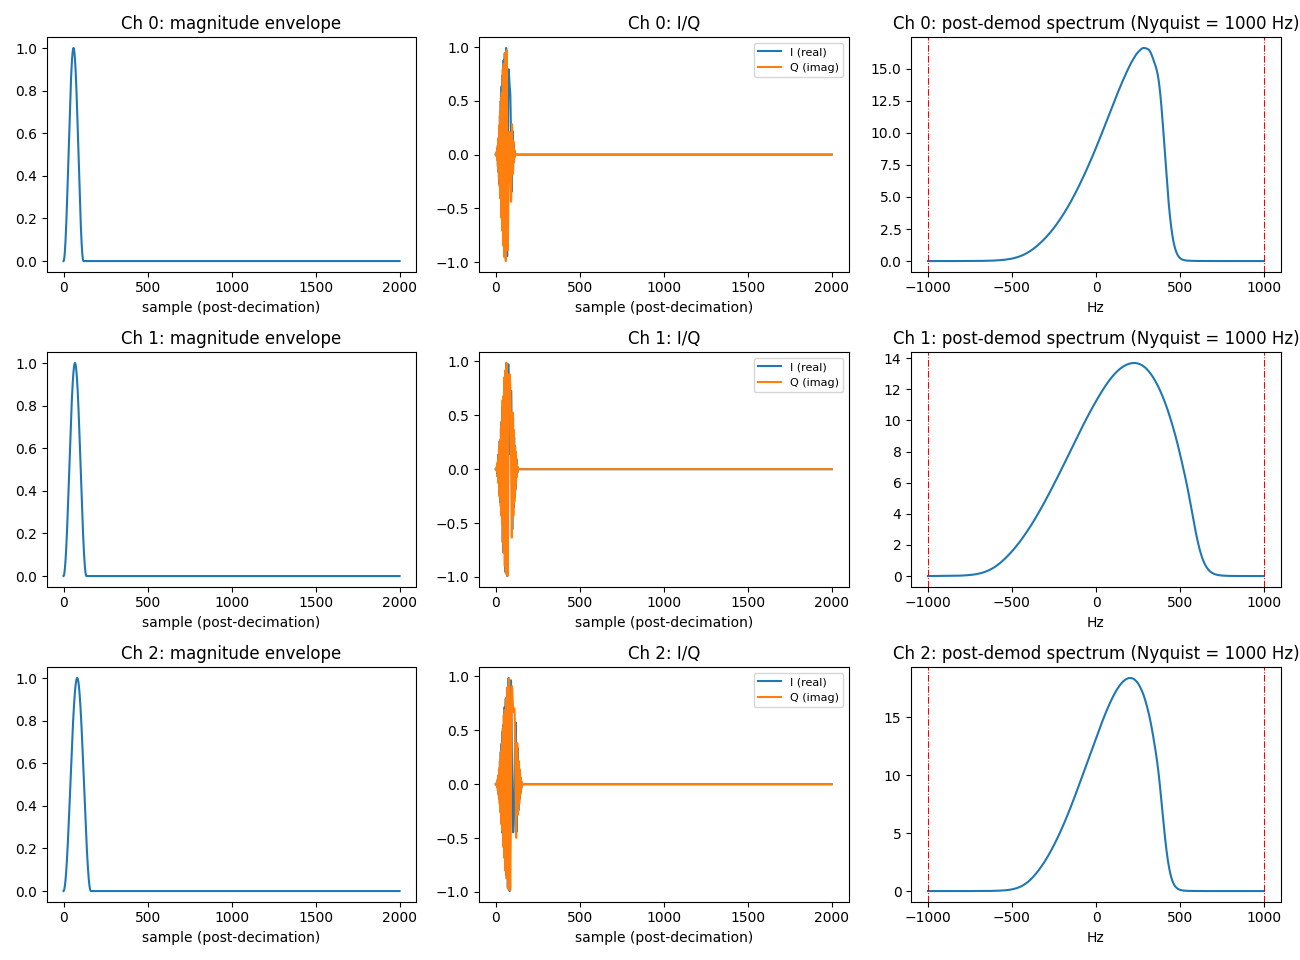

In [3]:
# Import BLR / AudioFrontEnd from 03_dnn/frontend.py
#
# frontend.py itself does `from config import ...`, resolved via its own
# sys.path adjustment relative to __file__, so it doesn't matter that this
# notebook lives in 01_poc/ rather than 03_dnn/. We just need 03_dnn/ itself
# on sys.path so `import frontend` (rather than `frontend.py`'s internal
# import of config) can be found.

import torch

FRONTEND_DIR = os.path.join(REPO_ROOT, '03_dnn')
sys.path.insert(0, FRONTEND_DIR)
from frontend import BLR, AudioFrontEnd

blr = BLR(bandwidth=NEW_BLR_TARGET_BW, fs=FS)
print(blr)
print(f"Decimation factor (FS / bandwidth): {blr.down}")


# In[ ]:


# Build a few representative chirplet kernels near the recommended max-safe MAX_BW

torch.manual_seed(0)
np.random.seed(0)

N_KERNELS = 3
util.MAX_BW = RECOMMENDED_MAX_BW  # use the newly-found max-safe bandwidth for kernel design

kernels_np = []
padded_np = []
for _ in range(N_KERNELS):
    dur = pick_val(MIN_DUR_MS, MAX_DUR_MS)
    deg = pick_val(MIN_DEGREE, MAX_DEGREE)
    bw, fc = pick_bw_fc()
    f1, f2 = bw_fc_to_f1f2(bw, fc)
    ch = pchirp(f1, f2, dur, deg)
    kernels_np.append(ch)
    chp = np.pad(ch, (0, int(FS * T - len(ch))))
    padded_np.append(chp)

# Kernels: pad to a common (max) kernel length, shape [C, kernel_len] - used only for fce estimation
max_klen = max(len(k) for k in kernels_np)
kernels_padded = np.stack([np.pad(k, (0, max_klen - len(k))) for k in kernels_np])
kernels = torch.tensor(kernels_padded, dtype=torch.float32)

# x: the zero-padded chirplets themselves stand in as the "filtered output" impulse response,
# shape [B=1, C, L]
x = torch.tensor(np.stack(padded_np), dtype=torch.float32).unsqueeze(0)

print(f"kernels shape: {tuple(kernels.shape)}")
print(f"x shape: {tuple(x.shape)}")


# In[ ]:


# Run through BLR

with torch.no_grad():
    y = blr(x, kernels)  # complex, shape [B=1, C, L_out]

print(f"Output shape: {tuple(y.shape)}")
print(f"Expected output length (BW * duration): {int(NEW_BLR_TARGET_BW * T)}")


# In[ ]:


# Diagnostic plots - magnitude envelope, I/Q, and post-demod spectrum, per kernel

y_np = y.squeeze(0).numpy()  # [C, L_out]
FS_new = NEW_BLR_TARGET_BW  # decimation-only BLR: output rate == bandwidth

fig, axs = plt.subplots(N_KERNELS, 3, figsize=(13, 3.2 * N_KERNELS), squeeze=False)

for c in range(N_KERNELS):
    yc = y_np[c]
    mag = np.abs(yc)

    axs[c, 0].plot(mag)
    axs[c, 0].set_title(f"Ch {c}: magnitude envelope")
    axs[c, 0].set_xlabel("sample (post-decimation)")

    axs[c, 1].plot(np.real(yc), label='I (real)')
    axs[c, 1].plot(np.imag(yc), label='Q (imag)')
    axs[c, 1].set_title(f"Ch {c}: I/Q")
    axs[c, 1].set_xlabel("sample (post-decimation)")
    axs[c, 1].legend(fontsize=8)

    f_res = np.fft.fftshift(np.fft.fftfreq(len(yc), 1. / FS_new))
    YR = np.fft.fftshift(np.fft.fft(yc))
    axs[c, 2].plot(f_res, np.abs(YR))
    axs[c, 2].axvline(-FS_new / 2, color='r', linestyle='-.', linewidth=0.75)
    axs[c, 2].axvline(FS_new / 2, color='r', linestyle='-.', linewidth=0.75)
    axs[c, 2].set_title(f"Ch {c}: post-demod spectrum (Nyquist = {FS_new/2:.0f} Hz)")
    axs[c, 2].set_xlabel("Hz")

plt.tight_layout()
plt.show()